In [1]:
using PyPlot
using FFTW
using Random

# Riesz kernels on the torus

We plot $h:z\in [0,1]\mapsto K_{s,d}(z,0,\dots,0)$ where $K_{s,d}$ is the Riesz kernel of order $s$ on the $d$-torus, that is, the solution to $(-\Delta)^{s} K_{s,d}=\delta_0-1$. We normalize $h$ via an affine map so that $h(1/4)=1$ and $h(1/2)=0$.

In [2]:
# dimension 1 : kernel and its gradient
f1(x, s, cut=100)= 2*sum((2π*k)^(-2s)*cos(2π*k*x) for k = 1:cut)
g1(x, s, cut=100)= -2*sum((2π*k)^(1-2s)*sin(2π*k*x) for k = 1:cut)
# dimension 2
f2(x, s, cut=100)= 4*sum((2π*sqrt(k1^2+k2^2))^(-2s)*cos(2π*k1*x) for k1 = 1:cut, k2=1:cut)
# NB: since we truncate Fourier Series, it might be beneficial to convolve with a box before
# (or multiply coeffs by sinc(π k/(cut+1))
f3(x, s, cut=100)= 8*sum((2π*sqrt(k1^2+k2^2+k3^2))^(-2s)*cos(2π*k1*x) for k1 = 1:cut, k2=1:cut, k3=1:cut)

f3 (generic function with 2 methods)

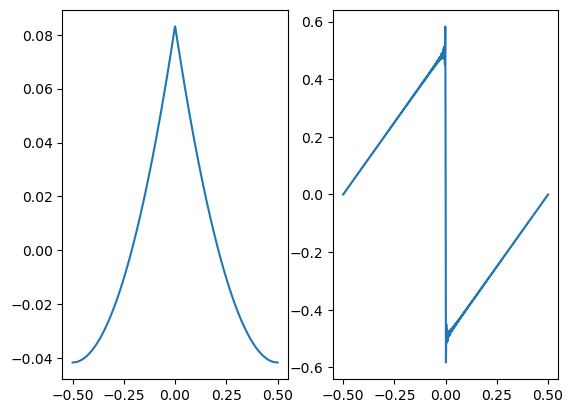

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fb220a5dd00>

In [3]:
x = range(-0.5,0.5,length=1000)
s = 1.0
subplot(121)
plot(x,f1.(x,1.0,300))
subplot(122)
plot(x,g1.(x,1.0,300))
#plot(x[1:end-1],(f1.(x[2:end],1.0,300) .- f1.(x[1:end-1],1.0,300))*1000)

 17.813209 seconds (636.55 k allocations: 36.956 MiB, 0.05% gc time, 0.52% compilation time)


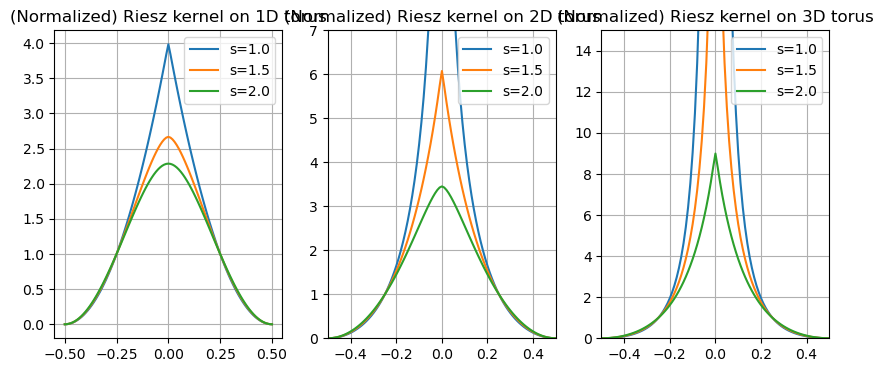

PyObject <matplotlib.legend.Legend object at 0x7fb1e0303c10>

In [4]:
x = range(-0.5,0.5,length=101)
ind = findfirst(x .== -0.25)
s = [1,1.5,2]
figure(figsize=[10,4])

subplot(131)
for si in s
y = real.(f1.(x,si,100))
y = y .- minimum(y)

plot(x,  y./y[ind],label="s=$(si)")
end
title("(Normalized) Riesz kernel on 1D torus")
grid("on")
legend()

subplot(132)
for si in s
y = real.(f2.(x,si,100))
y = y .- minimum(y)
y = y./y[ind]
plot(x,  y,label="s=$(si)")
end
grid("on")
axis([-0.5,0.5,0,7])
title("(Normalized) Riesz kernel on 2D torus")
legend()

subplot(133)
@time for si in s
y = real.(f3.(x,si,100))
y = y .- minimum(y)
y = y./y[ind]
plot(x,  y,label="s=$(si)")
end
grid("on")
axis([-0.5,0.5,0,15])
title("(Normalized) Riesz kernel on 3D torus")
legend()

# Some density processing functions

Everything on the 1D torus identified with [0,1] (with 0 and 1 glued).

In [6]:
"""
Generate a random density on [0,1] in H^γ a.s for gamma<c and *not* in H^γ a.s. for γ>c. 
To ensure strict positivity, the output is a mixture with uniform: (1-θ)*ν + θ*unif([0,1])
Output is discretized on N regular grid points.
"""
function random_sobolev_density(N, c, θ=0.5)
    θ = clamp(θ,0,1)
    # Fourier wavenumbers (FFT ordering)
    k = vcat(0:N÷2, -N÷2+1:-1)
    ω = 2π .* k
    
    ν̂ = zeros(ComplexF64, N)
    for j in 2:N   # skip zero mode
        ν̂[j] = (randn() + im*randn()) / abs(k[j])^(c+1/2)
    end
    ν̂[1] = 0.0          # zero mean before normalization

    ν = real(ifft(ν̂))
    ν .= ν .- minimum(ν)
    ν ./= sum(ν) /N #now ν is a proba with min density 0
    ν .= (1-θ)*ν.+ θ   # ensure strict positivity
    return ν
end

random_sobolev_density

In [7]:
"Approximate a discretized 1D probability density f with a sum of M Diracs of mass 1/M (uses quantiles)."
function density_to_atomic(f, M)
    N = length(f)
    x = ((1:N) .- 0.5)/N # bin centers (interpret the density as piecewise constant = f_i in bin x_i+[-1/(2N), 1/(2N)])
    loc = zeros(M) # init Dirac locations
    CDF = [0;cumsum(f)/N] # length N+2 (the last 1 is just to avoid bugs)
    ind = 1
    for i = 1:M
        while (ind < N) && (CDF[ind] .<= (i - 0.5)/M)
            ind += 1
        end
        loc[i] = x[ind-1] + (x[ind]-x[ind-1])*((i-0.5)/M - CDF[ind-1])/(CDF[ind] - CDF[ind-1])
    end
    return loc
end

density_to_atomic

In [8]:
"Show the density associated with a sum of M Diracs of mass weights and locations locs, on a grid of width N."
function atomic_to_density(locs, weights, N)
    locs = sort(locs)
    M = length(locs)
    f = zeros(N)
    j = 1
    for i in 1:N
        while j<=M && locs[j] < i/N
            f[i] += weights[j]*N
            j += 1
        end
    end
    return f
end

atomic_to_density

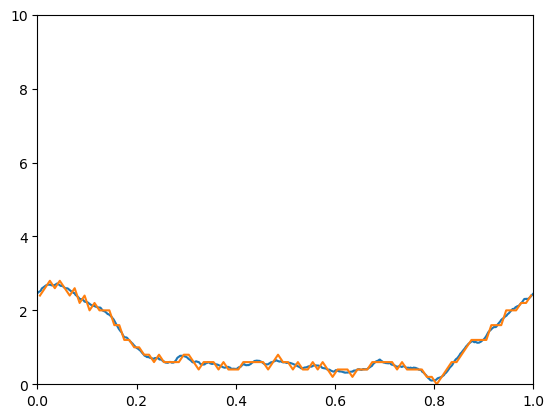

(0.0, 1.0, 0.0, 10.0)

In [9]:
N = 1024
NN = 100
M = 500
ν = random_sobolev_density(N, 1.0,0.1)
locs = density_to_atomic(ν, M)
f = atomic_to_density(locs, ones(length(locs))/M, NN)
plot((1:N)/N,ν)
plot(((1:NN) .- 1/2)/NN,f)
#stem(locs, ones(M))
axis([0,1,0,10])

# 1D simulation with upwind scheme

In [10]:
function simulation_PDE(s, ρ0, ν; n_steps, max_LR)
    N = length(ρ0)
    @assert length(ν) ==  N 
    dx     = 1.0 / N
    CFL = 0.5
    x = range(0, 1, length = N) # grid
    k = vcat(0:N÷2, -N÷2+1:-1)  
    ω = 2π .* k       # Fourier wavenumbers (FFT ordering)
    mult = [0.0 ; [-im * ω[j] / abs(ω[j])^(2s) for j in 2:N]] # ∇ (-Δ)^{-s} operatore
    
    # --------------------------------------------------------
    # Time stepping
    # --------------------------------------------------------

    ρs = zeros(N, n_steps) # tracks density
    ts = zeros(n_steps)    # tracks time evolution (we use nonuniform time-steps)
    errors = zeros(n_steps) # tracks || ρ_t - ν ||_{Ḣ^s}
        
    t = 0.0
    step = 0
    ρ = ρ0
    
    while step < n_steps
        
        step += 1
        ρs[:,step] = ρ
        ts[step] = t
        
        # Compute velocity v
        f  = ρ .- ν
        f̂ = fft(f)
        v̂ = mult .* f̂
        v  = real(ifft(v̂))
        
        errors[step] = sqrt(sum(abs2.(f̂[2:end]) ./ abs.(ω[2:end]).^(2s)) * dx)

        # CFL time step
        vmax = maximum(abs.(v))
        dt = vmax > 0 ? CFL * dx / vmax : 1e-2
        dt = min(dt, max_LR)

        # Upwind finite-volume flux
        F = zeros(N)

        for j in 1:N
            jp = j == N ? 1 : j + 1
            vhalf = 0.5 * (v[j] + v[jp])

            if vhalf ≥ 0
                F[j] = vhalf * ρ[j]
            else
                F[j] = vhalf * ρ[jp]
            end
        end

        ρnew = similar(ρ)
        for j in 1:N
            jm = (j == 1 ? N : j - 1)
            ρnew[j] = ρ[j] - (dt/dx) * (F[j] - F[jm])
        end

        # Positivity fix + renormalization
        ρnew .= max.(ρnew, 0.0)
        ρnew ./= sum(ρnew) * dx
        
        ρ = ρnew
        t += dt
       
    end
    
    return ρs, ts, errors
end

simulation_PDE (generic function with 1 method)

# Nice illustration s=2

In [876]:
Random.seed!(3)
# grid
N  = 1024
x = range(0, 1, length = N)

# initial density
ρ0 = ones(N)
γ_0 = 2.0
ρ0  = random_sobolev_density(N, γ_0 ,0.1)

#target density
γ_ν = 2.0
ν  = random_sobolev_density(N, γ_ν ,0.1)

# run PDE
s  = 2
ρs, ts, errors = simulation_PDE(s, ρ0, ν, n_steps=50000, max_LR=10);

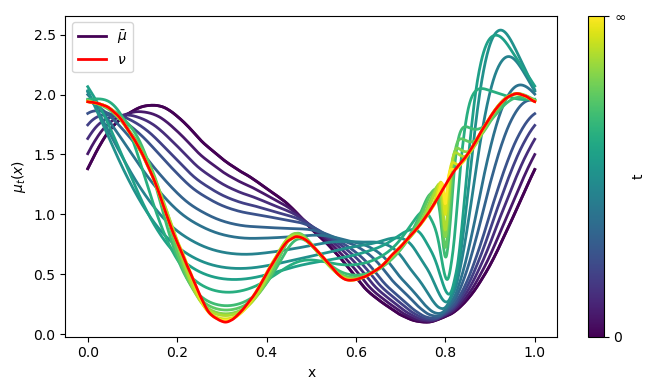

In [886]:
using PyPlot


iplot=[1;25;50;75;100; 140; 180;  240;  300; 350;  400;  500;  600;    800;   1000;  2000;  4000]
K  = length(iplot)
t  = range(0, 2; length=K)
fig, ax = subplots(figsize=(7,4))

base = get_cmap("viridis")
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "viridis_trunc",
    base.(range(0.0, 1.0; length=256))
)
norm = matplotlib.colors.Normalize(vmin=first(t), vmax=last(t))

# This is the "mappable" that will power the colorbar
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Matplotlib quirk: needed for colorbar sometimes

ax.plot(x, ρs[:,iplot[1]], color=cmap(norm(0)), linewidth=2,alpha=1.0,label=L"\bar \mu")
for (k, tk) in enumerate(t)
    ax.plot(x, ρs[:,iplot[k]], color=cmap(norm(tk)), linewidth=2,alpha=1.0)
end
plot(x, ν, "r", lw = 2,label=L"\nu")

ax.set_xlabel("x")
ax.set_ylabel(L"\mu_t(x)")
#ax.set_title("1D evolution")

cb = fig.colorbar(sm, ax=ax)
cb.set_label("t")
legend()

fig.tight_layout()
cb.set_ticks([0, 2.0])
cb.set_ticklabels(["0", L"\infty"])
savefig("evol_2_2_s2.png",dpi=150,bbox_inches="tight")

# Comparison convergence rates

In [921]:
Random.seed!(1)
# grid
N  = 8*1024
s  = 2
x = range(0, 1, length = N)
m = 0.2


γ_0,γ_ν = (2,2)
ρ0  = random_sobolev_density(N, γ_0 ,m)
ν  = random_sobolev_density(N, γ_ν ,m)
rate1 = -(min(γ_0,γ_ν)+s)/(2*(s-1))
ρs1, ts1, errors1 = simulation_PDE(s, ρ0, ν, n_steps=20000, max_LR=40);

γ_0,γ_ν = (0.5,0.5)
ρ0  = random_sobolev_density(N, γ_0 ,m)
ν  = random_sobolev_density(N, γ_ν ,m)
rate2 = -(min(γ_0,γ_ν)+s)/(2*(s-1))
ρs2, ts2, errors2= simulation_PDE(s, ρ0, ν, n_steps=20000, max_LR=40);

γ_0,γ_ν = (0.5,2)
ρ0  = random_sobolev_density(N, γ_0 ,m)
ν  = random_sobolev_density(N, γ_ν ,m)
rate3 = -(min(γ_0,γ_ν)+s)/(2*(s-1))
ρs3, ts3, errors3 = simulation_PDE(s, ρ0, ν, n_steps=20000, max_LR=40);

γ_0,γ_ν = (2,0.5)
ρ0  = random_sobolev_density(N, γ_0 ,m)
ν  = random_sobolev_density(N, γ_ν ,m)
rate4 = -(min(γ_0,γ_ν)+s)/(2*(s-1))
ρs4, ts4, errors4 = simulation_PDE(s, ρ0, ν, n_steps=20000, max_LR=40);

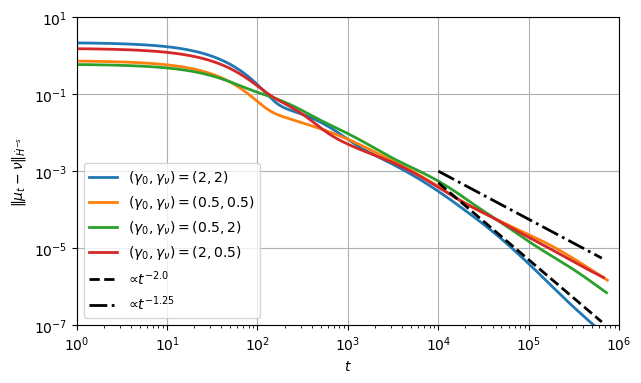

In [927]:
figure(figsize=[7;4])
loglog(ts1,errors1  ,label=L"(\gamma_0,\gamma_\nu)=(2,2)",lw=2)
loglog(ts2,errors2  ,label=L"(\gamma_0,\gamma_\nu)=(0.5,0.5)",lw=2)
loglog(ts3,errors3  ,label=L"(\gamma_0,\gamma_\nu)=(0.5,2)",lw=2)
loglog(ts4,errors4  ,label=L"(\gamma_0,\gamma_\nu)=(2,0.5)",lw=2)
Ind = findfirst(ts1 .> 1e4)
loglog(ts1[Ind:end], 5e4*ts1[Ind:end] .^ (rate1),"--k",label = "\$∝ t^{$(rate1)}\$",lw=2)
#loglog(ts1[Ind:end], 5e7*ts1[Ind:end] .^ (rate1),"--k",label = "\$∝ t^{$(rate1)}\$",lw=2)
loglog(ts1[Ind:end], 100*ts1[Ind:end] .^ (rate2),"-.k",label= "\$∝t^{$(rate2)}\$",lw=2)
grid("on")
axis([1e0,10e5,1e-7,10])
legend()
xlabel(L"t")
ylabel(L"\Vert \mu_t-\nu\Vert_{\dot{H}^{-s}}")
savefig("errors_s2.png",dpi=150,bbox_inches="tight")

# Coulombian case

### Varying regularity

In [865]:
Random.seed!(5)
# grid
N  = 4*1024
s  = 1
x = range(0, 1, length = N)

γ_0,γ_ν = (1,3)
ρ0  = random_sobolev_density(N, γ_0 ,0.2)
ν  = random_sobolev_density(N, γ_ν ,0.2)
ρs1, ts1, errors1 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);

γ_0,γ_ν = (3,3)
ρ0  = random_sobolev_density(N, γ_0 ,0.2)
ν  = random_sobolev_density(N, γ_ν ,0.2)
ρs2, ts2, errors2 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);

γ_0,γ_ν = (3,1)
ρ0  = random_sobolev_density(N, γ_0 ,0.2)
ν  = random_sobolev_density(N, γ_ν ,0.2)
ρs3, ts3, errors3 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);

γ_0,γ_ν = (1,1)
ρ0  = random_sobolev_density(N, γ_0 ,0.2)
ν  = random_sobolev_density(N, γ_ν ,0.2)
ρs4, ts4, errors4 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);

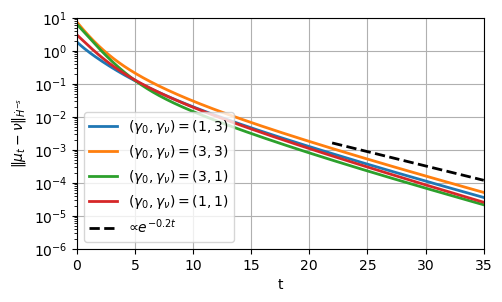

In [875]:
figure(figsize=[7*3/4,3])
semilogy(ts1,errors1,label=L"(\gamma_0,\gamma_\nu)=(1,3)",lw=2)
semilogy(ts2,errors2,label=L"(\gamma_0,\gamma_\nu)=(3,3)",lw=2)
semilogy(ts3,errors3,label=L"(\gamma_0,\gamma_\nu)=(3,1)",lw=2)
semilogy(ts4,errors4,label=L"(\gamma_0,\gamma_\nu)=(1,1)",lw=2)
ind = findfirst(ts1 .> 25)
semilogy(ts4[ind:end],1.3e-1*exp.(-0.2*ts4[ind:end]),label=L"∝e^{-0.2t}",lw=2,"--k")
axis([0,35,1e-6,1e1])
legend(loc=3)
grid("on")
xlabel("t")
ylabel(L"\Vert \mu_t-\nu\Vert_{\dot{H}^{-s}}")
#savefig("errors_s1.png",dpi=150,bbox_inches="tight")

### Varying lower bound

In [851]:
Random.seed!(5)
# grid
N  = 4*1024
s  = 1
x = range(0, 1, length = N)
m1,m2 = 0.1, 0.4

γ_0,γ_ν = (1,1)
ρ0  = random_sobolev_density(N, γ_0 ,m2)
ν  = random_sobolev_density(N, γ_ν ,m2)

ρs1, ts1, errors1 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);


ρ0  = random_sobolev_density(N, γ_0 ,m2)
ν  = random_sobolev_density(N, γ_ν ,m1)
ρs2, ts2, errors2 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);


ρ0  = random_sobolev_density(N, γ_0 ,m1)
ν  = random_sobolev_density(N, γ_ν ,m2)
ρs3, ts3, errors3 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);


ρ0  = random_sobolev_density(N, γ_0 ,m1)
ν  = random_sobolev_density(N, γ_ν ,m1)
ρs4, ts4, errors4 = simulation_PDE(s, ρ0, ν, n_steps=5000, max_LR=0.01);

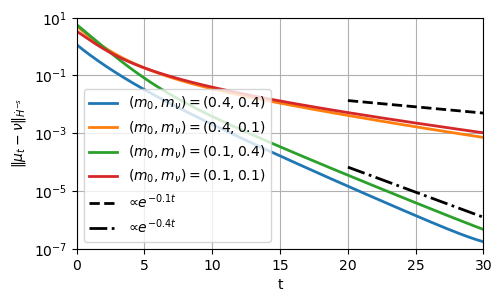

In [863]:
figure(figsize=[7*3/4,3])
semilogy(ts1,errors1,label=L"(m_0,m_\nu)=(0.4,0.4)",lw=2)
semilogy(ts2,errors2,label=L"(m_0,m_\nu)=(0.4,0.1)",lw=2)
semilogy(ts3,errors3,label=L"(m_0,m_\nu)=(0.1,0.4)",lw=2)
semilogy(ts4,errors4,label=L"(m_0,m_\nu)=(0.1,0.1)",lw=2)
ind = findfirst(ts4 .> 20)
semilogy(ts4[ind:end],0.1*exp.(-m1* ts4[ind:end]),label=L"∝e^{-0.1t}","--k",lw=2)
semilogy(ts4[ind:end],0.2*exp.(-m2* ts4[ind:end] ),label=L"∝e^{-0.4t}","-.k",lw=2)
axis([0,30,1e-7,1e1])
legend()
grid("on")
xlabel("t")
ylabel(L"\Vert \mu_t-\nu\Vert_{\dot{H}^{-s}}")
#savefig("errors_s1_lb.png",dpi=150,bbox_inches="tight")

### Observe exponential filling of holes

In [800]:
Random.seed!(2)
N  = 1024
s  = 1
x = range(0, 1, length = N)

# initial density
ρ0 = ones(N)
γ_0 = 1.0
ρ0  = random_sobolev_density(N, γ_0 ,0.1)
ρ0 = max.(ρ0 .- 0.8,0.0) # last two lines to creat holes
ρ0 = ρ0 *N ./ (sum(ρ0))

#target density
γ_ν = 1.0
ν  = random_sobolev_density(N, γ_ν ,0.1)
ν = max.(ν .- 0.0,0.0) # last two lines to creat holes
ν = ν *N ./ (sum(ν))

ρs, ts, errors = simulation_PDE(s, ρ0, ν, n_steps=2000, max_LR=0.01);

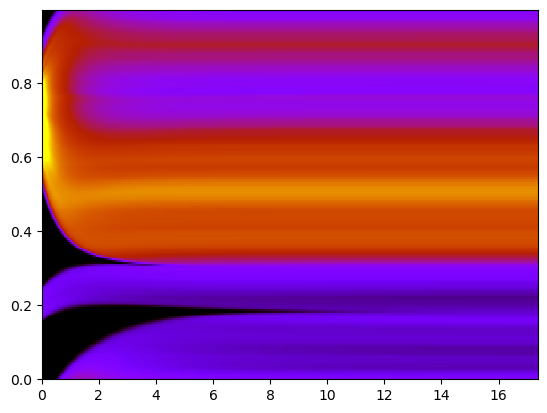

PyObject <matplotlib.collections.PolyCollection object at 0x7fe2f082ee80>

In [801]:
pcolor(ts[1:5:end],x[1:5:end], ρs[1:5:end,1:5:end],cmap="gnuplot",vmax=2.5,vmin=0)

sys:1: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


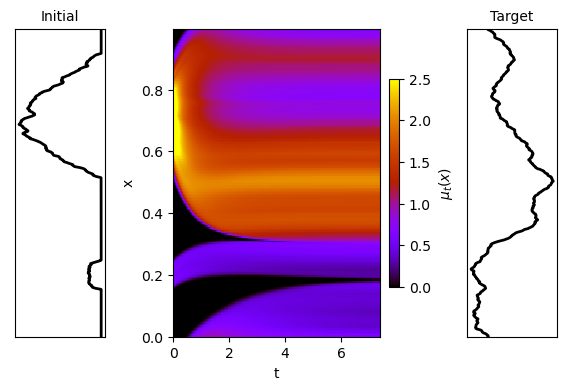

In [806]:

# -----------------------------
# Figure layout
# -----------------------------
fig = figure(figsize=(7,4))

# width ratios: left density | main evolution | right density
gs = fig.add_gridspec(1, 3, width_ratios=[1, 2.5, 1], wspace=0.5)

ax_left  = fig.add_subplot(gs[1])
ax_main  = fig.add_subplot(gs[2])
ax_right = fig.add_subplot(gs[3])

# -----------------------------
# Center: PDE evolution
# -----------------------------
#pc = ax_main.pcolormesh(t, x, U', shading="auto", cmap="cividis")
pc = ax_main.pcolor(ts[1:5:div(end,2)],x[1:5:end], ρs[1:5:end,1:5:div(end,2)],cmap="gnuplot",vmax=2.5,vmin=0)

ax_main.set_xlabel("t")
ax_main.set_ylabel("x")

# -----------------------------
# Left: initial density
# -----------------------------
ax_left.plot(ρ0, x, color="black", lw=2)
ax_left.set_ylim(x[1], x[end])
ax_left.invert_xaxis()          # face inward
ax_left.set_xticks([])
ax_left.set_yticks([])

ax_left.set_title("Initial", fontsize=10)

# -----------------------------
# Right: final density (mirrored)
# -----------------------------
ax_right.plot(ν, x, color="black", lw=2)
ax_right.set_ylim(x[1], x[end])
ax_right.set_xticks([])
ax_right.set_yticks([])

ax_right.set_title("Target", fontsize=10)

# -----------------------------
# Colorbar
# -----------------------------
cb = fig.colorbar(pc, ax=ax_main, fraction=0.046, pad=0.04)
cb.set_label(L"\mu_t(x)")

fig.tight_layout()
savefig("density_s1_lb.png",dpi=150,bbox_inches="tight")

# 1D simulation with particles (this section not used in the paper)

In [502]:
"This version is slower because we recompute the kernel and its gradient at each iteration."
function simulation_particles(s, loc_ρ0, loc_ν, n_steps, step_size)
    M1 = length(loc_ρ0)
    M2 = length(loc_ν)
    cut = 50
    locs = zeros(M1, n_steps) # tracks locations of the M1 moving particles
    ts = range(0,length = n_steps, step = step_size)   # tracks time evolution (we use nonuniform time-steps)
    errors = zeros(n_steps) # tracks || ρ_t - ν ||_{Ḣ^s}
    vectBB = mod.(loc_ν .- loc_ν' .+ 0.5, 1.0) .- 0.5
    cst = sum(f1.(vectBB, s, cut))/(M2^2) # used in the computation of the \dot{H}^{-s} distance
    loc = loc_ρ0

    
    for k in 1:n_steps
        locs[:,k] = loc       
        vectAB = mod.(loc .- loc_ν' .+ 0.5, 1.0) .- 0.5
        vectAA = mod.(loc .- loc' .+ 0.5, 1.0) .- 0.5
        grad = (2*sum(g1.(vectAA, s, cut ), dims=2)/M1 .- 2*sum(g1.(vectAB, s, cut), dims=2)/M2)[:]
        loc = mod.(loc .- step_size * grad, 1.0)
        errors[k] = sqrt(sum(f1.(vectAA, s, cut))/(M1^2) - 2*sum(f1.(vectAB, s, cut))/(M1*M2) + cst +1e-9)
    end
    
    return locs, ts, errors
end

simulation_particles (generic function with 1 method)

In [728]:
function simulation_particles_precompute(s, loc_ρ0, loc_ν; n_steps, LR)
    M1 = length(loc_ρ0)
    M2 = length(loc_ν)
    
        
    # precompute the kernels at good precision
    cut = 200
    res = 10001 # take odd to properly deal with 0
    grid = (0:res) ./ res .- 0.5
    tab1 = f1.(grid , s, cut )
    tab2 = g1.(grid , s, cut )
   
    locs = zeros(M1, n_steps) # tracks locations of the M1 moving particles
    ts = range(0,length = n_steps, step = LR)   # tracks time evolution
    errors = zeros(n_steps) # tracks || ρ_t - ν ||_{Ḣ^s}
    
    vectBB = mod.(loc_ν .- loc_ν' .+ 0.5, 1.0)
    kBB = linear_interp(tab1, vectBB) # +0.5 as function defined on [0,1]
    cst = sum(kBB)/(M2^2) # used in the computation of the \dot{H}^{-s} distance
    loc = loc_ρ0

    
    for k in 1:n_steps
        
        locs[:,k] = loc   
    
        vectAB = mod.(loc .- loc_ν' .+ 0.5, 1.0)
        vectAA = mod.(loc .- loc' .+ 0.5, 1.0)
        kAB = linear_interp(tab1, vectAB)
        kAA = linear_interp(tab1, vectAA)
        gAB = linear_interp(tab2, vectAB)
        gAA = linear_interp(tab2, vectAA)
        
        errors[k] = sqrt(sum(kAA)/(M1^2) - 2*sum(kAB)/(M1*M2) + cst)
        
        grad = (2*sum(gAA, dims=2)/M1 .- 2*sum(gAB, dims=2)/M2)[:]
        loc = mod.(loc .- LR * grad, 1.0)
    end
    
    return locs, ts, errors
end

simulation_particles_precompute (generic function with 2 methods)

implement the linear interpolation

In [672]:
"""
From an array of discete values f_1=f(0),...,f_N=f(1) of a function [0,1]→ R, and query values x[1], ..., x[K],
return f(x[1]),...,f(x[K]) using linear interpolation between tabulated values.
"""
function linear_interp(f,x)
    N = length(f)
    K = length(x)
    I = min.(Int.(floor.((N-1)*x)) .+ 1, N-1)
    r = (N-1) .* x .-  (I .- 1) # in [0,1]
    r, (I .- 1) ./ (N-1)
    v = (1 .- r) .* f[I] .+ r.* f[I .+ 1] # linear interpolation
    return v
end
# beware to map on [-0.5,0.5] in the use case (instead on [0,1])

linear_interp

In [745]:
N = 1024
M1, M2 = 500, 200
γ_0 = 1.0
γ_ν = 1.0
s  = 1.6
Random.seed!(1)

# initial density
ρ0 = ones(N)
ρ0  = random_sobolev_density(N, γ_0 ,0.2)
#ρ0 = max.(ρ0 .- 0.8,0.0) # last two lines to creat holes
#ρ0 = ρ0 *N ./ (sum(ρ0))
loc_ρ0 = density_to_atomic(ρ0, M1)

#target density

ν  = random_sobolev_density(N, γ_ν ,0.1)
#ν = max.(ν .- 0.8,0.0) # last two lines to creat holes
#ν = ν *N ./ (sum(ν))
loc_ν = density_to_atomic(ν, M2)

# run PDE

@time ρs1, ts1, errors1 = simulation_PDE(s, ρ0, ν, n_steps=10000, max_LR=1);
@time locs2, ts2, errors2 = simulation_particles_precompute(s, loc_ρ0, loc_ν, n_steps=10000, LR=1);

  0.688204 seconds (200.02 k allocations: 1.395 GiB, 3.73% gc time)
 68.019083 seconds (860.03 k allocations: 443.764 GiB, 2.20% gc time)


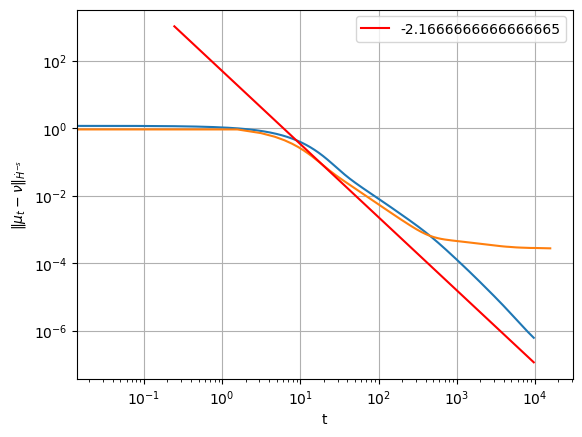

PyObject <matplotlib.legend.Legend object at 0x7f77b6967f10>

In [746]:
loglog(ts1,errors1)
loglog((π/2)*ts2,errors2*errors1[1]/errors2[1])
#loglog(ts3,errors3*M1)
rate = -(min(γ_0,γ_ν)+s)/(2*(s-1))
loglog(ts1[10:end], 50*ts1[10:end] .^ (rate),"r",label="$(rate)")
grid("on")
#axis([10,maximum([ts1;ts2]),1e-5,1])
xlabel("t")
ylabel(L"\Vert \mu_t-\nu\Vert_{\dot{H}^{-s}}")
legend()

# RELU NN experiments

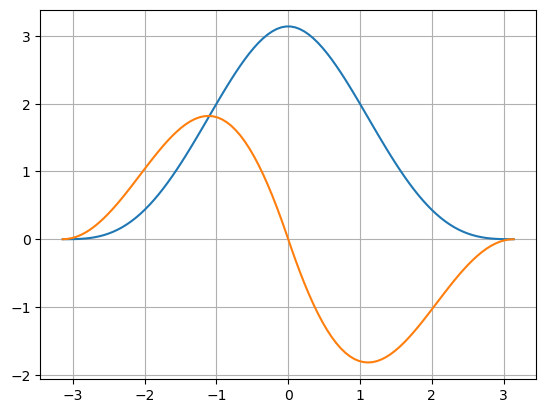

In [14]:
# arcos kernel and its derivative
ak(θ) = sin(abs(θ)) + (π-abs(θ))*cos(θ)
dak(θ) = (abs(θ)-π)*sin(θ)
θs = range(-π,π,length=100)
plot(θs, ak.(θs))
plot(θs,  dak.(θs))
grid("on")

In [15]:
"Wasserstein gradient flow"
function WGF_particles_RELU(loc_ρ0, loc_ν; n_steps, LR)
    
    M1 = length(loc_ρ0)
    M2 = length(loc_ν)
    
    locs = zeros(M1, n_steps) # tracks locations of the M1 moving particles
    ts = range(0,length = n_steps, step = LR)   # tracks time evolution (we use nonuniform time-steps)
    objs = zeros(n_steps) # tracks objective
    vectBB = mod.(loc_ν .- loc_ν' .+ 0.5, 1.0) .- 0.5 # in [-0.5,0.5]
    cst = sum(ak.(2π*vectBB))/(M2^2) # used in the computation of the \dot{H}^{-s} distance
    loc = loc_ρ0

    
    for k in 1:n_steps
        locs[:,k] = loc       
        vectAB = mod.(loc .- loc_ν' .+ 0.5, 1.0) .- 0.5
        vectAA = mod.(loc .- loc' .+ 0.5, 1.0) .- 0.5
        grad = 2π*(2*sum(dak.(2π*vectAA), dims=2)/M1 .- 2*sum(dak.(2π*vectAB), dims=2)/M2)[:]
        loc = mod.(loc .- LR * grad, 1.0)
        objs[k] = sum(ak.(2π*vectAA))/(M1^2) - 2*sum(ak.(2π*vectAB))/(M1*M2) + cst
    end
    
    return locs, ts, objs
end

WGF_particles_RELU (generic function with 1 method)

In [760]:
"Wasserstein-Fisher-Rao gradient flow"
function WFRGF_particles_RELU(loc_ρ0, loc_ν; n_steps, LR)
    
    M1 = length(loc_ρ0)
    M2 = length(loc_ν)
    
    locs = zeros(M1, n_steps) # tracks locations of the M1 moving particles
    weights = zeros(M1, n_steps) # tracks weights of the M1 moving particles
    #ts = range(0,length = n_steps, step = LR)  # tracks time evolution (we use nonuniform time-steps)
    ts = zeros(n_steps)
    objs = zeros(n_steps) # tracks objective
    vectBB = mod.(loc_ν .- loc_ν' .+ 0.5, 1.0) .- 0.5 # in [-0.5,0.5]
    cst = sum(ak.(2π*vectBB))/(M2^2) # used in the computation of the \dot{H}^{-s} distance
    loc = loc_ρ0
    w   = ones(M1)
    t   = 0
    
    for k in 1:n_steps
        locs[:,k] = loc 
        weights[:,k]= w
        ts[k] = t
        vectAB = mod.(loc .- loc_ν' .+ 0.5, 1.0) .- 0.5
        vectAA = mod.(loc .- loc' .+ 0.5, 1.0) .- 0.5
        grad_loc = 2π*(2*sum( (w .* w') .* dak.(2π*vectAA), dims=2)/M1 .- 2*sum( (w .* ones(M2)') .* dak.(2π*vectAB), dims=2)/M2)[:]
        # we put here a factor 40 otherwise FR part is negligible
        grad_weights = 4 * w .*(2*sum( (w .* w') .* ak.(2π*vectAA), dims=2)/M1 .- 2*sum( (w .* ones(M2)') .* ak.(2π*vectAB), dims=2)/M2)[:]
        η = LR#min(k^(1/2)*LR,10*LR)
        loc = mod.(loc .- η  * grad_loc, 1.0)
        w   = w .- η  * grad_weights
        t   += η 
        objs[k] = sum( (w .* w') .* ak.(2π*vectAA))/(M1^2) - 2*sum( (w .* ones(M2)') .* ak.(2π*vectAB))/(M1*M2) + cst
    end
    
    return locs, weights, ts, objs
end

WFRGF_particles_RELU (generic function with 1 method)

In [765]:
N = 1024
M1, M2 = 800, 800
γ_0 = Inf
γ_ν = 3
Random.seed!(1)

# initial and target densities
ρ0 = ones(N)
#ρ0  = random_sobolev_density(N, γ_0 ,0.2)
loc_ρ0 = density_to_atomic(ρ0, M1)
ν  = random_sobolev_density(N, γ_ν ,0.1)
loc_ν = density_to_atomic(ν, M2)

# run PDE
@time locs_RELU_W, ts_RELU_W, objs_RELU_W = WGF_particles_RELU(loc_ρ0, loc_ν; n_steps=1000, LR=0.005);
@time locs_RELU_WFR, weights_RELU_WFR, ts_RELU_WFR, objs_RELU_WFR = WFRGF_particles_RELU(loc_ρ0, loc_ν; n_steps=1000, LR=0.005);

γ_0 = Inf
γ_ν = 1

# initial and target densities
ρ0 = ones(N)
#ρ0  = random_sobolev_density(N, γ_0 ,0.2)
loc_ρ0 = density_to_atomic(ρ0, M1)
ν  = random_sobolev_density(N, γ_ν ,0.1)
loc_ν = density_to_atomic(ν, M2)

# run PDE
@time locs_RELU_W2, ts_RELU_W2, objs_RELU_W2 = WGF_particles_RELU(loc_ρ0, loc_ν; n_steps=1000, LR=0.005);
@time locs_RELU_WFR2, weights_RELU_WFR2, ts_RELU_WFR2, objs_RELU_WFR2 = WFRGF_particles_RELU(loc_ρ0, loc_ν; n_steps=1000, LR=0.005);

 32.874043 seconds (39.02 k allocations: 47.772 GiB, 0.13% gc time)
 52.931543 seconds (70.02 k allocations: 66.943 GiB, 0.11% gc time)
 33.049278 seconds (39.02 k allocations: 47.772 GiB, 0.11% gc time)
 53.332861 seconds (70.02 k allocations: 66.943 GiB, 0.10% gc time)


sys:1: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.


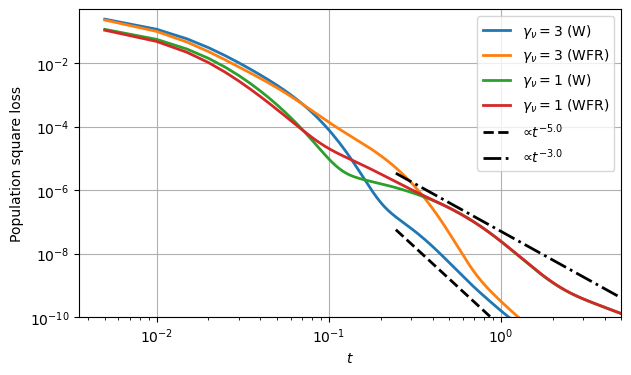

In [807]:
figure(figsize=[7,4])
loglog(ts_RELU_W .+ ts_RELU_W[2], objs_RELU_W,lw=2,label=L"$\gamma_{\nu} = 3$ (W)")
loglog(ts_RELU_WFR .+ ts_RELU_WFR[2], objs_RELU_WFR,lw=2,label=L"$\gamma_{\nu} = 3$ (WFR)")
loglog(ts_RELU_W2 .+ ts_RELU_W2[2], objs_RELU_W2,lw=2,label=L"$\gamma_{\nu} = 1$ (W)")
loglog(ts_RELU_WFR2 .+ ts_RELU_WFR2[2], objs_RELU_WFR2,lw=2,label=L"$\gamma_{\nu} = 1$ (WFR)")
s=2.0
rate1 = -2*(3+s)/(2*(s-1))
loglog(ts_RELU_W[50:end], 0.00000000005*(ts_RELU_W[50:end] .^ (rate1)),"--k",label = "\$∝ t^{$(rate1)}\$",lw=2)
rate1 = -2*(1+s)/(2*(s-1))
loglog(ts_RELU_W[50:end], 0.00000005*(ts_RELU_W[50:end] .^ (rate1)),"-.k",label = "\$∝ t^{$(rate1)}\$",lw=2)
grid("on")
axis([0,5,1e-10,0.5])
legend()
grid("on")
xlabel(L"t")
ylabel("Population square loss")
savefig("relu_errors.png",dpi=150,bbox_inches="tight")

Observe evolution of densities

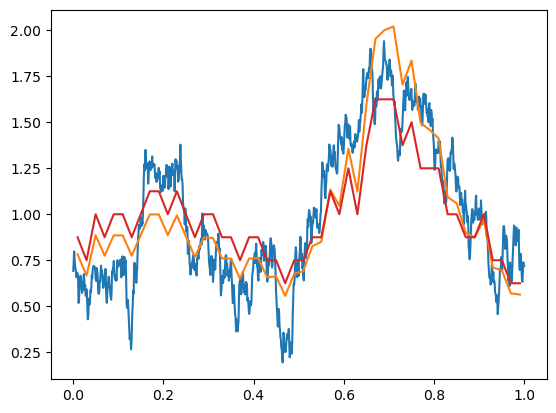

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fe5bc4dfe50>

In [204]:
t=1000
NN = 50
f_mu = atomic_to_density(locs_RELU_WFR[:,t], weights_RELU_WFR[:,t]/M1, NN)
f_mu2 = atomic_to_density(locs_RELU_WFR[:,1000], ones(M1)/M1, NN)
plot(((1:N) .-0.5)./N,ν)
plot(((1:NN) .-0.5)./NN, f_mu)
plot(((1:NN) .-0.5)./NN, f_mu2,"C3")